In [2]:
import numpy as np
import matplotlib.pyplot as plt

from argosim.antenna_utils import *
from argosim.plot_utils import *
from argosim.data_utils import *
from argosim.clean import *
from argosim.imaging_utils import *

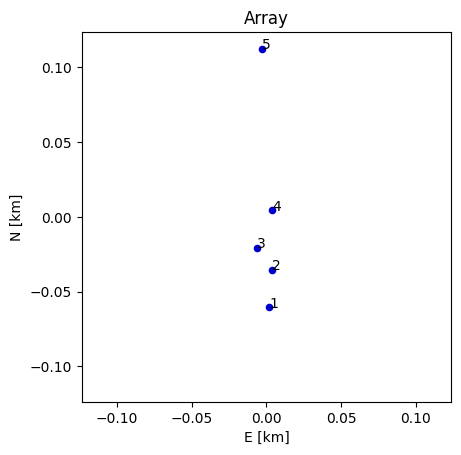

In [3]:
antenna = load_antenna_enu_txt('../configs/arrays/argos_pathfinder.enu.txt')
plot_antenna_arr(antenna)

In [4]:
# Exemple of how to save an antenna array:
#save_antenna_enu_txt(antenna,'./antenna_config.txt')

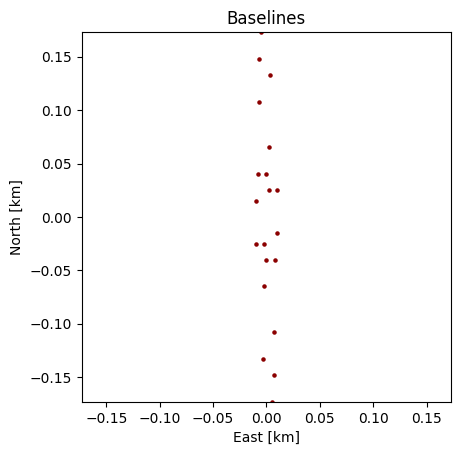

In [5]:
baselines = get_baselines(antenna)
plot_baselines(baselines, ENU=True)

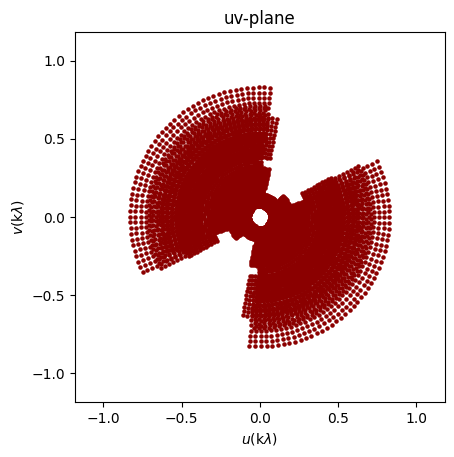

In [6]:
# Multiband parameters
bandwidth = 1000e6
n_freqs = 11
f = 2000e6 # 2 GHz, lambda = 0.15 m

# Source tracking parameters
source_decl = 90./180*np.pi
array_lat = 35./180*np.pi # Heraklion latitud
track_time = 8
delta_t = 10/60 # 600 segs
t_0 = -0.5
n_times = int(track_time/delta_t)

track, _ = uv_track_multiband(baselines, array_lat, source_decl, track_time, t_0, n_times, f, bandwidth, n_freqs)

plot_baselines(track)

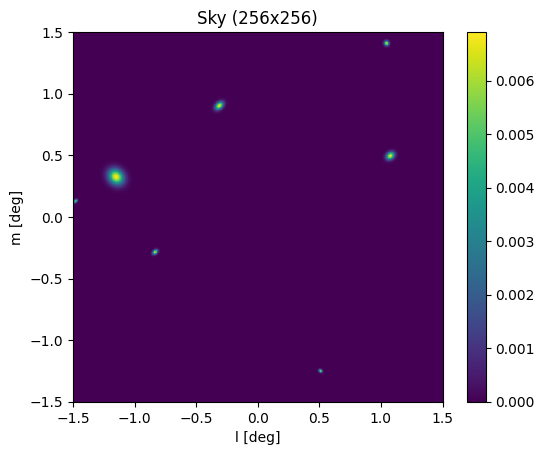

In [7]:
Npx = 256
fov_size = (3., 3.) # 3 degrees FOV from 6 m parabolic dishes.
deg_size_list = np.array([.1, .05, .05, .03, .03, .02, .02])
source_intensity_list = [1]*len(deg_size_list)
sky = n_source_sky((Npx, Npx), fov_size[0], deg_size_list, source_intensity_list, seed=43)
plot_sky(sky, fov_size)

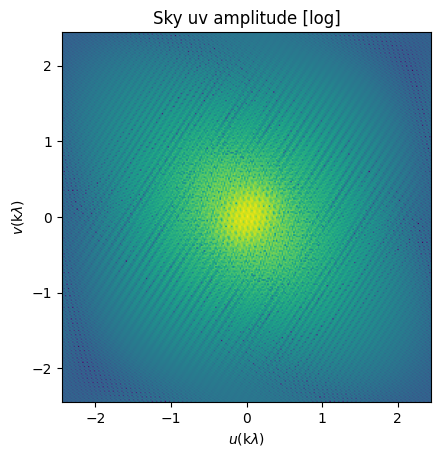

In [8]:
# Fourier transform of the sky
sky_uv = sky2uv(sky)
plot_sky_uv(sky_uv, fov_size, title='Sky uv amplitude [log]', scale='log')

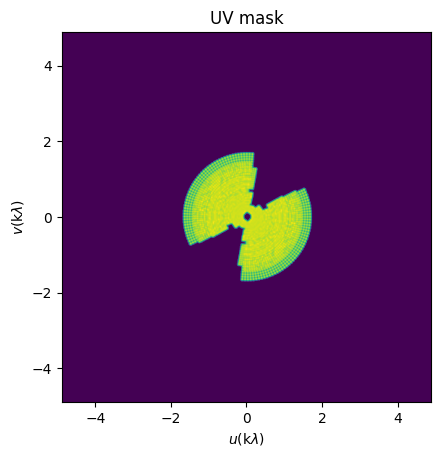

In [9]:
# Fourier transform of the mask
uv_mask, _ = grid_sampling_function(track, fov_size[0], sky_uv.shape[0], weighting='uniform')
plot_sky_uv(uv_mask, fov_size, title='UV mask', scale='log')

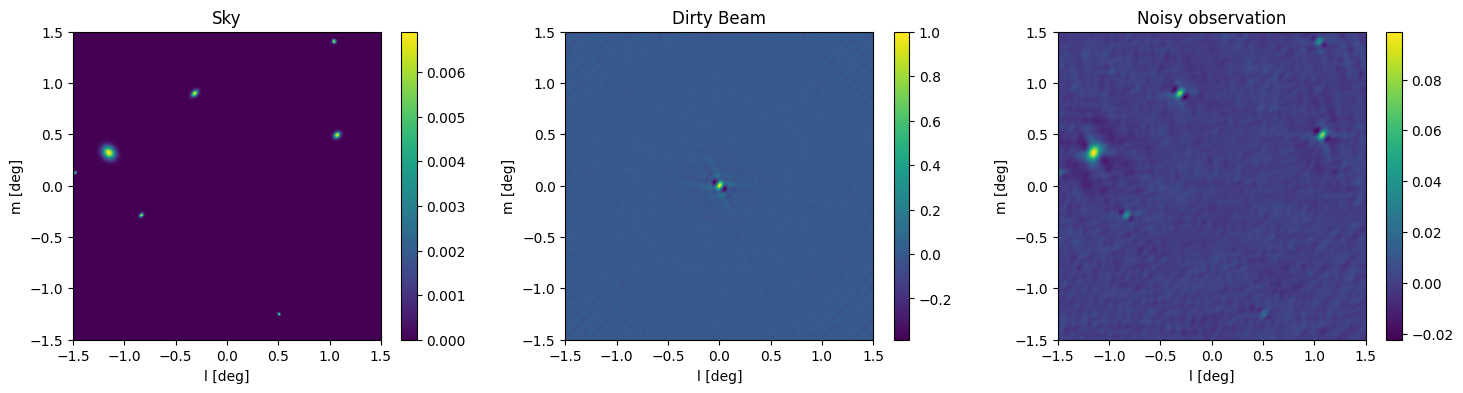

In [16]:
obs, dirty_beam = simulate_dirty_observation(sky, track, fov_size[0], sigma=0.1, weighting='uniform')

fig, ax = plt.subplots(1, 3, figsize=(18,4))
plot_sky(sky, fov_size, ax[0], fig, 'Sky')
plot_sky(dirty_beam, fov_size, ax[1], fig, 'Dirty Beam')
plot_sky(obs, fov_size, ax[2], fig, 'Noisy observation')

In [17]:
from scipy.signal import convolve2d

Estimated clean beam size (FWHM): 5.15 px


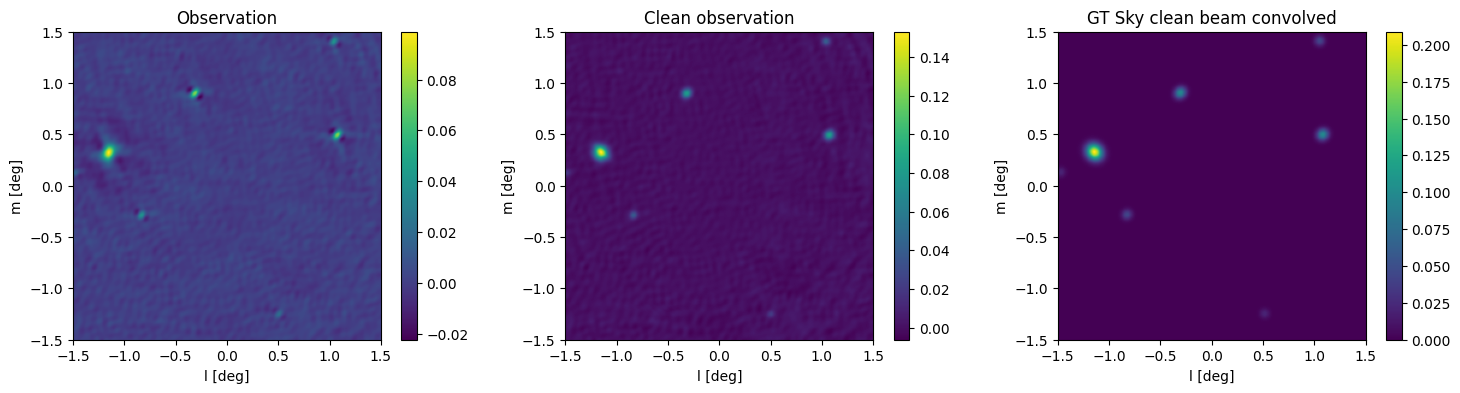

In [18]:
I_clean, sky_model = clean_hogbom(obs, dirty_beam, gamma=0.1, max_iter=2000, threshold=1e-5, res=True)

# Clean beam
clean_beam = gauss_source(
    dirty_beam.shape[1], dirty_beam.shape[0], np.array([0, 0]), fwhm_pix=fit_elliptical_beam(dirty_beam)["width"]
)
# Convlolve sky with clean beam
sky_conv = convolve2d(sky, clean_beam, mode='same')

# Plot clean observation
fig, ax = plt.subplots(1, 3, figsize=(18,4))
plot_sky(obs, fov_size, ax[0], fig, 'Observation')
plot_sky(I_clean, fov_size, ax[1], fig, 'Clean observation')
plot_sky(sky_conv, fov_size, ax[2], fig, 'GT Sky clean beam convolved')

# plt.savefig('/home/figures/clean_observation.pdf')
plt.show()